In [37]:
"""
================================================================================
FUZZY REGRESSION DISCONTINUITY DESIGN (Fuzzy RDD)
================================================================================

PROBLEM STATEMENT
-----------------
You are a Data Scientist at a large health insurance company. The company
launched a "High-Risk Care Management Program" for members who score >= 70 on an
internal health risk score (0-100). Members above the threshold are ENCOURAGED
to enroll in the program (phone coaching, nurse outreach, medication reminders),
but enrollment is not mandatory -- some high-risk members opt out, and a small
fraction of lower-risk members are manually enrolled by their physicians.

This is the classic Fuzzy RDD setup:
  - There is a SHARP cutoff (score = 70) that determines TREATMENT ELIGIBILITY
  - But actual TREATMENT TAKE-UP is imperfect (fuzzy), not a perfect step function
  - We want to estimate the LOCAL AVERAGE TREATMENT EFFECT (LATE) of enrollment
    on 90-day hospitalization costs

You will:
  1. Simulate Dataset A: where enrollment GENUINELY reduces costs (true causal effect)
  2. Simulate Dataset B: where enrollment has NO effect (null case)
  3. Apply Fuzzy RDD to both and interpret results correctly


------------------------------------------
1. Sharp vs Fuzzy RDD:
   - Sharp RDD: treatment jumps from 0 to 1 deterministically at cutoff
   - Fuzzy RDD: probability of treatment jumps at cutoff, but not from 0 to 1

2. The core idea -- two discontinuities:
   - First discontinuity: the First Stage. The probability of being enrolled jumps at score = 70
   - Second discontinuity: the Reduced Form. The average outcome (cost) also jumps at score = 70
   - Reduced form: jump in Outcome at the cutoff
   - LATE = Reduced Form jump / First Stage jump  (this is IV / Wald estimator)

3. Fuzzy RDD IS an Instrumental Variable (IV) estimator:
   - Instrument Z = 1(score >= threshold)
   - Z predicts treatment (first stage), but affects outcome ONLY through treatment
   - Exclusion restriction: being above cutoff only affects costs via enrollment
   - Fuzzy RDD is just IV where the instrument is a threshold indicator, 
   - and where you restrict to a local window around that threshold to make the randomization assumption more credible.

4. Identifying assumptions:
   - Continuity: potential outcomes are smooth through the cutoff (no other policy
     changes exactly at score = 70)
   - Local randomization: near the cutoff, assignment is as good as random
   - Monotonicity: crossing the threshold only increases (never decreases) P(treatment)
   - No precise manipulation: members cannot precisely control their score to game
     the threshold

5. LATE vs ATE:
   - Fuzzy RDD identifies LATE for "compliers" -- members who enroll BECAUSE they
     crossed the threshold. It does NOT give you the ATE for the full population.

6. Bandwidth selection:
   - The key bias-variance tradeoff in RDD
   - Too narrow: high variance, few observations
   - Too wide: more bias if the running variable's relationship with outcome is
     nonlinear far from the cutoff
   - IK (Imbens-Kalyanaraman) or CCT (Calonico-Cattaneo-Titiunik) optimal bandwidth
     is the gold standard

7. Falsification / diagnostic tests:
   - McCrary density test: check for bunching/manipulation at the cutoff
   - Placebo cutoffs: run RDD at fake thresholds -- should find no effect
   - Baseline covariate smoothness: pre-treatment covariates should NOT jump at cutoff
   - Donut hole: exclude observations right at the cutoff to test robustness

8. Polynomial order:
   - Local linear regression (order=1) is recommended by most methodologists
   - Higher-order polynomials can overfit and produce spurious effects at boundaries

================================================================================
"""

'\n================================================================================\nFUZZY REGRESSION DISCONTINUITY DESIGN (Fuzzy RDD)\n================================================================================\n\nPROBLEM STATEMENT\n-----------------\nYou are a Data Scientist at a large health insurance company. The company\nlaunched a "High-Risk Care Management Program" for members who score >= 70 on an\ninternal health risk score (0-100). Members above the threshold are ENCOURAGED\nto enroll in the program (phone coaching, nurse outreach, medication reminders),\nbut enrollment is not mandatory -- some high-risk members opt out, and a small\nfraction of lower-risk members are manually enrolled by their physicians.\n\nThis is the classic Fuzzy RDD setup:\n  - There is a SHARP cutoff (score = 70) that determines TREATMENT ELIGIBILITY\n  - But actual TREATMENT TAKE-UP is imperfect (fuzzy), not a perfect step function\n  - We want to estimate the LOCAL AVERAGE TREATMENT EFFECT (LATE

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.formula.api import ols

np.random.seed(42)
CUTOFF = 70          # Risk score threshold for program eligibility
N = 3000             # Sample size
BANDWIDTH = 15       # Bandwidth around cutoff for local estimation

In [93]:
#Generate 2 datasets
# Dataset 1: There is an effect
# Dataset 2: There is no effect

In [95]:
#Build dataset
def generate_dataset(n, cutoff, true_effect, seed=42, label=""):
    """
    Simulate a Fuzzy RDD dataset.

    Parameters
    ----------
    n          : int   -- number of members
    cutoff     : float -- eligibility threshold on running variable
    true_effect: float -- causal effect of enrollment on cost (0 = null case)
    seed       : int
    label      : str   -- name for the dataset

    Running variable: health risk score (0-100), continuous
    Treatment:        enrolled in care management program (fuzzy)
    Outcome:          90-day hospitalization cost ($)
    """
    rng = np.random.default_rng(seed)

    # --- Running variable: health risk score ---
    # Drawn from a mixture to look realistic; no manipulation at cutoff
    score = rng.uniform(30, 100, n)

    # --- Instrument: above the cutoff ---
    above = (score >= cutoff).astype(int)

    # --- Fuzzy treatment: P(enroll) jumps at cutoff but is imperfect ---
    # Below cutoff: ~15% enroll (physician override)
    # Above cutoff: ~75% enroll (encouraged but not forced)
    p_enroll_below = 0.15
    p_enroll_above = 0.75
    p_enroll = np.where(above == 1, p_enroll_above, p_enroll_below)
    enrolled = rng.binomial(1, p_enroll)

    # --- Potential outcomes ---
    # Baseline cost increases with risk score (sicker = more expensive)
    baseline_cost = 2000 + 40 * score + rng.normal(0, 800, n)

    # Causal effect of enrollment: reduces cost by `true_effect` dollars
    # (true_effect = 0 in null dataset, true_effect = -2500 in effect dataset)
    cost = baseline_cost + true_effect * enrolled

    df = pd.DataFrame({
        'score': score,
        'above_cutoff': above,
        'enrolled': enrolled,
        'cost': cost,
        'score_centered': score - cutoff   # center at cutoff for regression
    })

    print(f"\n{'='*60}")
    print(f"Dataset: {label}")
    print(f"{'='*60}")
    print(f"N = {n:,}  |  Cutoff = {cutoff}  |  True effect = ${true_effect:,.0f}")
    print(f"\nFirst stage (take-up rates):")
    print(f"  Below cutoff: {df[df.above_cutoff==0].enrolled.mean():.1%} enrolled")
    print(f"  Above cutoff: {df[df.above_cutoff==1].enrolled.mean():.1%} enrolled")
    print(f"\nOutcome summary (mean 90-day cost):")
    print(f"  Below cutoff: ${df[df.above_cutoff==0].cost.mean():,.0f}")
    print(f"  Above cutoff: ${df[df.above_cutoff==1].cost.mean():,.0f}")

    return df

In [96]:
def fuzzy_rdd(df, cutoff, bandwidth, label=""):
    """
    Estimate Fuzzy RDD using 2SLS (IV) with local linear regression.

    Steps:
      1. Restrict to bandwidth window [cutoff - bw, cutoff + bw]
      2. First stage:  regress enrolled ~ above_cutoff + score_centered + interaction
      3. Reduced form: regress cost    ~ above_cutoff + score_centered + interaction
      4. LATE = reduced form coefficient / first stage coefficient
         (equivalently, run 2SLS directly)

    Returns dict with estimates and standard errors.
    """
    print(f"\n{'='*60}")
    print(f"Fuzzy RDD Estimation -- {label}")
    print(f"Bandwidth: +/- {bandwidth} points around cutoff={cutoff}")
    print(f"{'='*60}")

    # --- Step 1: Bandwidth restriction ---
    mask = (df.score >= cutoff - bandwidth) & (df.score <= cutoff + bandwidth)
    local = df[mask].copy()
    print(f"Observations in bandwidth: {len(local):,} of {len(df):,}")

    # Allow different slopes on each side (interaction term)
    # Model: Y = a + b*above + c*score_centered + d*(above*score_centered)
    local['interact'] = local['above_cutoff'] * local['score_centered']

    # --- Step 2: First Stage ---
    # Does crossing the cutoff increase P(enrollment)?
    X_fs = sm.add_constant(local[['above_cutoff', 'score_centered', 'interact']])
    fs_model = sm.OLS(local['enrolled'], X_fs).fit(cov_type='HC3')
    fs_jump = fs_model.params['above_cutoff']
    fs_pval = fs_model.pvalues['above_cutoff']
    fs_fstat = fs_model.fvalue  # F-stat for instrument strength (want > 10)

    print(f"\nFirst Stage (DV = enrolled):")
    print(f"  Jump at cutoff: {fs_jump:.3f}  (p={fs_pval:.4f})")
    print(f"  F-statistic:    {fs_fstat:.1f}  {'[STRONG]' if fs_fstat > 10 else '[WEAK - caution]'}")

    # --- Step 3: Reduced Form ---
    # Does crossing the cutoff change outcomes (even ignoring enrollment)?
    X_rf = sm.add_constant(local[['above_cutoff', 'score_centered', 'interact']])
    rf_model = sm.OLS(local['cost'], X_rf).fit(cov_type='HC3')
    rf_jump = rf_model.params['above_cutoff']
    rf_pval = rf_model.pvalues['above_cutoff']

    print(f"\nReduced Form (DV = cost):")
    print(f"  Jump at cutoff: ${rf_jump:,.0f}  (p={rf_pval:.4f})")

    # --- Step 4: LATE via Wald estimator ---
    # LATE = Reduced Form / First Stage
    late_wald = rf_jump / fs_jump

    # Delta method SE for ratio: SE(b/a) ~ sqrt(SE_b^2/a^2 + b^2*SE_a^2/a^4)
    se_rf = rf_model.bse['above_cutoff']
    se_fs = fs_model.bse['above_cutoff']
    se_late = np.sqrt(
        (se_rf**2 / fs_jump**2) +
        (rf_jump**2 * se_fs**2 / fs_jump**4)
    )
    t_stat = late_wald / se_late
    p_late = 2 * (1 - stats.t.cdf(abs(t_stat), df=len(local)-5))
    ci_low = late_wald - 1.96 * se_late
    ci_high = late_wald + 1.96 * se_late

    print(f"\nLATE (Wald / IV Estimate):")
    print(f"  LATE = ${late_wald:,.0f}  (SE=${se_late:,.0f})")
    print(f"  t-stat: {t_stat:.2f}  |  p-value: {p_late:.4f}")
    print(f"  95% CI: [${ci_low:,.0f},  ${ci_high:,.0f}]")
    if p_late < 0.05:
        print(f"  >> Statistically significant at 5% level")
    else:
        print(f"  >> NOT statistically significant -- consistent with no effect")

    return {
        'local': local,
        'fs_jump': fs_jump, 'fs_pval': fs_pval, 'fs_fstat': fs_fstat,
        'rf_jump': rf_jump, 'rf_pval': rf_pval,
        'late': late_wald, 'se_late': se_late,
        'ci_low': ci_low, 'ci_high': ci_high,
        'p_late': p_late,
        'fs_model': fs_model, 'rf_model': rf_model
    }

In [98]:
# ---------------------------------------------------------------------
# WHAT fuzzy_rdd() JUST DID:
# This is the main engine. It ran the actual Fuzzy RDD in 4 steps:
#
# STEP 1 -- Zoom in (bandwidth restriction):
#   Threw away everyone with a score far from 70.
#   Kept only members scoring between 55 and 85 (if bandwidth=15).
#   Why? Because near the cutoff the two groups are nearly identical.
#   Far from the cutoff they are very different people -- not a fair comparison.
#
# STEP 2 -- First Stage:
#   Asked: does crossing score=70 actually increase enrollment?
#   Fit a regression line on each side and measured the jump in P(enrolled).
#   If this jump is small or the F-stat is below 10, the instrument is weak
#   and we cannot trust the LATE estimate at all.
#
# STEP 3 -- Reduced Form:
#   Asked: does crossing score=70 change costs directly?
#   Same structure as Step 2 but the outcome is cost, not enrollment.
#   This is the raw jump in the thing we care about at the threshold.
#
# STEP 4 -- Wald Estimator (LATE):
#   Divided the reduced form jump by the first stage jump.
#   This scales up the cost jump to account for the fact that not everyone
#   above the cutoff enrolled. The result is the cost effect PER ENROLLED PERSON.
#   Also computed standard error, confidence interval, and p-value.
#
# The interaction term (above * score_centered) allows the slope of the
# cost-vs-score line to be different on each side of the cutoff.
# ---------------------------------------------------------------------

In [100]:
def bin_data(df, cutoff, n_bins=30):
    """
    Bin the running variable into equal-width bins and compute mean outcome
    and mean enrollment per bin. Used for plotting.
    """
    below = df[df.score < cutoff].copy()
    above = df[df.score >= cutoff].copy()

    def make_bins(d, n):
        d = d.copy()
        d['bin'] = pd.cut(d['score'], bins=n)
        agg = d.groupby('bin', observed=True).agg(
            score_mid=('score', 'mean'),
            mean_cost=('cost', 'mean'),
            mean_enrolled=('enrolled', 'mean'),
            count=('cost', 'size')
        ).reset_index()
        return agg

    below_bins = make_bins(below, n_bins // 2)
    above_bins = make_bins(above, n_bins // 2)
    return below_bins, above_bins

In [101]:
# ---------------------------------------------------------------------
# WHAT bin_data() JUST DID:
# Solved the "3,000 dots on a chart looks like a blob" problem.
#
# It divided the score range into equal-width buckets, then computed
# the average cost and average enrollment rate inside each bucket.
# So instead of 3,000 chaotic scatter points, you get ~30 clean dots
# that clearly show the trend on each side of the cutoff.
#
# Think of it like rounding everyone's score to the nearest 2 points
# and averaging all members in that group together.
# A person scoring 68.3 and a person scoring 69.7 both land in the
# same bucket and get averaged into one clean dot.
#
# It keeps the below-cutoff and above-cutoff sides separate so the
# visual gap (the discontinuity) at score=70 is obvious in the charts.
# ---------------------------------------------------------------------

In [29]:
def plot_rdd(df, result, cutoff, bandwidth, dataset_label, true_effect):
    """
    Produce a 4-panel diagnostic figure for Fuzzy RDD.

    Panel 1: Raw scatter + binned means -- Outcome vs Running Variable
    Panel 2: First stage -- P(enrolled) vs Running Variable
    Panel 3: Local window zoom -- fitted lines on both sides
    Panel 4: Density plot of running variable (McCrary-style check)
    """
    below_bins, above_bins = bin_data(df, cutoff)
    local = result['local']

    fig = plt.figure(figsize=(16, 12))
    fig.suptitle(
        f"Fuzzy RDD Diagnostics -- {dataset_label}\n"
        f"True Effect: ${true_effect:,.0f}  |  "
        f"Estimated LATE: ${result['late']:,.0f} (p={result['p_late']:.3f})",
        fontsize=14, fontweight='bold', y=0.98
    )
    gs = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.3)

    colors = {'below': '#2196F3', 'above': '#E91E63', 'cutoff': '#FF6F00'}

    # ---- Panel 1: Outcome vs Running Variable ----
    ax1 = fig.add_subplot(gs[0, 0])

    # Faint scatter
    ax1.scatter(df[df.score < cutoff]['score'],
                df[df.score < cutoff]['cost'],
                alpha=0.05, s=8, color=colors['below'])
    ax1.scatter(df[df.score >= cutoff]['score'],
                df[df.score >= cutoff]['cost'],
                alpha=0.05, s=8, color=colors['above'])

    # Binned means
    ax1.scatter(below_bins['score_mid'], below_bins['mean_cost'],
                color=colors['below'], s=50, zorder=5, label='Below cutoff (bins)')
    ax1.scatter(above_bins['score_mid'], above_bins['mean_cost'],
                color=colors['above'], s=50, zorder=5, label='Above cutoff (bins)')

    # Fitted lines on each side using full data
    for side_df, color in [(df[df.score < cutoff], colors['below']),
                            (df[df.score >= cutoff], colors['above'])]:
        x = side_df['score'].values
        y = side_df['cost'].values
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 200)
        ax1.plot(x_line, p(x_line), color=color, linewidth=2)

    ax1.axvline(cutoff, color=colors['cutoff'], linestyle='--', linewidth=2,
                label=f'Cutoff = {cutoff}')
    ax1.set_title('Outcome: 90-Day Cost vs Risk Score', fontweight='bold')
    ax1.set_xlabel('Health Risk Score')
    ax1.set_ylabel('90-Day Cost ($)')
    ax1.legend(fontsize=8)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    # ---- Panel 2: First Stage -- P(enrolled) vs Running Variable ----
    ax2 = fig.add_subplot(gs[0, 1])

    # Binned enrollment rates
    ax2.scatter(below_bins['score_mid'], below_bins['mean_enrolled'],
                color=colors['below'], s=50, zorder=5, label='Below cutoff')
    ax2.scatter(above_bins['score_mid'], above_bins['mean_enrolled'],
                color=colors['above'], s=50, zorder=5, label='Above cutoff')

    # Fitted lines
    for side_df, color in [(df[df.score < cutoff], colors['below']),
                            (df[df.score >= cutoff], colors['above'])]:
        x = side_df['score'].values
        y = side_df['enrolled'].values
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 200)
        ax2.plot(x_line, p(x_line), color=color, linewidth=2)

    ax2.axvline(cutoff, color=colors['cutoff'], linestyle='--', linewidth=2,
                label=f'Cutoff = {cutoff}')
    ax2.set_title(f'First Stage: P(Enrolled) vs Risk Score\nJump = {result["fs_jump"]:.2f}  '
                  f'(F={result["fs_fstat"]:.0f})', fontweight='bold')
    ax2.set_xlabel('Health Risk Score')
    ax2.set_ylabel('P(Enrolled in Program)')
    ax2.set_ylim(-0.05, 1.05)
    ax2.legend(fontsize=8)

    # ---- Panel 3: Local window zoom -- cost, local linear fit ----
    ax3 = fig.add_subplot(gs[1, 0])
    local_below = local[local.above_cutoff == 0]
    local_above = local[local.above_cutoff == 1]

    ax3.scatter(local_below['score'], local_below['cost'],
                alpha=0.2, s=15, color=colors['below'])
    ax3.scatter(local_above['score'], local_above['cost'],
                alpha=0.2, s=15, color=colors['above'])

    # Local linear fits
    for side_df, color in [(local_below, colors['below']),
                            (local_above, colors['above'])]:
        x = side_df['score'].values
        y = side_df['cost'].values
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 200)
        ax3.plot(x_line, p(x_line), color=color, linewidth=2.5)

    # Annotate the jump
    y_below = np.polyval(np.polyfit(local_below.score, local_below.cost, 1), cutoff)
    y_above = np.polyval(np.polyfit(local_above.score, local_above.cost, 1), cutoff)
    ax3.annotate('', xy=(cutoff + 0.5, y_above), xytext=(cutoff + 0.5, y_below),
                 arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax3.text(cutoff + 1, (y_below + y_above) / 2,
             f'RF jump\n${result["rf_jump"]:,.0f}', fontsize=8, va='center')

    ax3.axvline(cutoff, color=colors['cutoff'], linestyle='--', linewidth=2)
    ax3.set_title(f'Local Window (+/- {bandwidth} pts)\nReduced Form Jump = ${result["rf_jump"]:,.0f}',
                  fontweight='bold')
    ax3.set_xlabel('Health Risk Score')
    ax3.set_ylabel('90-Day Cost ($)')
    ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    # ---- Panel 4: Density of running variable (McCrary test proxy) ----
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.hist(df[df.score < cutoff]['score'], bins=40,
             color=colors['below'], alpha=0.7, label='Below cutoff', density=True)
    ax4.hist(df[df.score >= cutoff]['score'], bins=40,
             color=colors['above'], alpha=0.7, label='Above cutoff', density=True)
    ax4.axvline(cutoff, color=colors['cutoff'], linestyle='--', linewidth=2,
                label=f'Cutoff = {cutoff}')
    ax4.set_title('Density of Running Variable\n(Manipulation check -- should be smooth)',
                  fontweight='bold')
    ax4.set_xlabel('Health Risk Score')
    ax4.set_ylabel('Density')
    ax4.legend(fontsize=8)

    # Annotation: no bunching expected
    ax4.text(0.05, 0.92, 'No bunching at cutoff\n= manipulation unlikely',
             transform=ax4.transAxes, fontsize=8,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.show()
    print(f"\nFigure saved.")

In [30]:
# ---------------------------------------------------------------------
# WHAT plot_rdd() JUST DID:
# Produced the main 4-panel diagnostic figure. Each panel checks one
# key part of the Fuzzy RDD story:
#
# PANEL 1 -- Outcome vs Running Variable (top left):
#   Shows the raw cost data and binned averages against risk score.
#   You are looking for a visible gap at score=70.
#   Dataset A: you will see costs drop right at the cutoff.
#   Dataset B: the line flows through smoothly, no gap.
#
# PANEL 2 -- First Stage (top right):
#   Shows P(enrolled) vs risk score.
#   You want an obvious jump at 70. No jump = no instrument = no RDD.
#   Also prints the jump size and F-statistic in the title.
#
# PANEL 3 -- Local Window Zoom (bottom left):
#   Zooms into just the bandwidth window (scores 55 to 85).
#   Fits a line on each side and draws an arrow showing the reduced
#   form jump in dollars. This is the most important panel --
#   the gap between the two lines at exactly score=70 is the
#   raw evidence of a causal effect before we scale by the first stage.
#
# PANEL 4 -- Density Check (bottom right):
#   Shows a histogram of how many members fall at each score level.
#   Checks for suspicious bunching just above or below 70.
#   A smooth histogram means nobody gamed their score.
#   A spike just above 70 would mean sick people are inflating their
#   scores to get into the program -- which would break the whole method.
# ---------------------------------------------------------------------

In [31]:
def plot_late_comparison(result_a, result_b):
    """
    Side-by-side LATE point estimates with 95% CIs for both datasets.
    Lets you visually compare: one with a significant effect, one without.
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    datasets = ['Dataset A\n(True Effect: -$2,500)', 'Dataset B\n(Null: No Effect)']
    lates = [result_a['late'], result_b['late']]
    ci_lows = [result_a['ci_low'], result_b['ci_low']]
    ci_highs = [result_a['ci_high'], result_b['ci_high']]
    pvals = [result_a['p_late'], result_b['p_late']]
    colors_bar = ['#E91E63', '#9E9E9E']

    for i, (label, late, lo, hi, pv, c) in enumerate(
            zip(datasets, lates, ci_lows, ci_highs, pvals, colors_bar)):
        ax.errorbar(i, late, yerr=[[late - lo], [hi - late]],
                    fmt='o', color=c, markersize=12,
                    elinewidth=2.5, capsize=8, capthick=2.5)
        sig = '** p<0.05' if pv < 0.05 else 'n.s.'
        ax.text(i, hi + 100, f'${late:,.0f}\n{sig}',
                ha='center', fontsize=10, fontweight='bold', color=c)

    ax.axhline(0, color='black', linestyle='--', linewidth=1.5,
               label='No effect (zero)')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(datasets, fontsize=11)
    ax.set_ylabel('LATE: Estimated Effect of Enrollment on Cost ($)', fontsize=10)
    ax.set_title('Fuzzy RDD -- LATE Estimates with 95% CI\nDataset A (Effect) vs Dataset B (Null)',
                 fontweight='bold', fontsize=12)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


In [32]:
# ---------------------------------------------------------------------
# WHAT plot_late_comparison() JUST DID:
# Drew the headline summary chart -- both LATE estimates side by side
# with their 95% confidence intervals as vertical error bars.
#
# What to look for:
#   Dataset A dot: should sit around -$2,500, CI does NOT cross zero
#                  --> statistically significant, real effect detected
#   Dataset B dot: should sit near $0, CI comfortably crosses zero
#                  --> not significant, correctly finds no effect
#
# This is the chart you would show an executive or in a paper.
# It answers the question "did the program work?" in one glance.
# If both dots look the same, your method is not working.
# If only Dataset A is significant, your method is doing its job.
# ---------------------------------------------------------------------

In [33]:
# ============================================================
# PLACEBO / FALSIFICATION TEST
# ============================================================

In [34]:
def placebo_cutoff_test(df, true_cutoff, bandwidth, n_placebo=20, label=""):
    """
    Run the RDD at fake cutoffs. If your method is working,
    you should ONLY find a significant effect at the true cutoff, not at
    arbitrary placebo cutoffs.

    We test 20 placebo cutoffs away from the real one and collect LATE estimates.
    A good result: real cutoff LATE is an outlier; placebos cluster near zero.
    """
    print(f"\n{'='*60}")
    print(f"Placebo Cutoff Test -- {label}")
    print(f"{'='*60}")

    # Placebo cutoffs away from the real one (avoid true cutoff +/- bandwidth)
    left_placebos = np.linspace(true_cutoff - 3*bandwidth, true_cutoff - bandwidth - 2,
                                n_placebo // 2)
    right_placebos = np.linspace(true_cutoff + bandwidth + 2, true_cutoff + 3*bandwidth,
                                 n_placebo // 2)
    placebo_cutoffs = np.concatenate([left_placebos, right_placebos])

    placebo_lates = []
    placebo_ses = []

    for pc in placebo_cutoffs:
        mask = (df.score >= pc - bandwidth) & (df.score <= pc + bandwidth)
        local = df[mask].copy()
        if len(local) < 50:
            continue
        local['score_c'] = local['score'] - pc
        local['above_p'] = (local['score'] >= pc).astype(int)
        local['interact_p'] = local['above_p'] * local['score_c']

        try:
            X = sm.add_constant(local[['above_p', 'score_c', 'interact_p']])
            fs = sm.OLS(local['enrolled'], X).fit()
            rf = sm.OLS(local['cost'], X).fit()
            late_p = rf.params['above_p'] / fs.params['above_p']
            se_p = np.sqrt(
                (rf.bse['above_p']**2 / fs.params['above_p']**2) +
                (rf.params['above_p']**2 * fs.bse['above_p']**2 / fs.params['above_p']**4)
            )
            placebo_lates.append(late_p)
            placebo_ses.append(se_p)
        except Exception:
            continue

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.errorbar(range(len(placebo_lates)), placebo_lates,
                yerr=[1.96 * s for s in placebo_ses],
                fmt='o', color='#9E9E9E', alpha=0.7, elinewidth=1, capsize=4,
                label='Placebo cutoffs (95% CI)')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Placebo Cutoff Index')
    ax.set_ylabel('Placebo LATE Estimate ($)')
    ax.set_title(f'Placebo Cutoff Test -- {label}\n'
                 f'Placebos should cluster near $0; true cutoff is significant if valid',
                 fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend()
    plt.tight_layout()
    plt.show()

    pct_sig = np.mean([abs(l) / s > 1.96
                       for l, s in zip(placebo_lates, placebo_ses)]) * 100
    print(f"% of placebo cutoffs significant at 5%: {pct_sig:.0f}%  (expect ~5% by chance)")
    return placebo_lates, placebo_ses

In [35]:
# ---------------------------------------------------------------------
# WHAT placebo_cutoff_test() JUST DID:
# Ran a sanity check: tested the RDD at 20 FAKE thresholds where
# we know the program does not kick in (like score=45 or score=88).
#
# The logic: if your method is genuinely detecting a real discontinuity
# at score=70, it should NOT find significant effects at random other
# scores. Those fake cutoffs have no special meaning -- nothing changes
# there -- so the LATE estimates should all cluster near $0.
#
# What a good result looks like:
#   All 20 placebo dots floating near zero, none significant.
#   About 1 out of 20 being significant by pure chance is normal (5%).
#   If 8 out of 20 are significant, something is wrong with your data
#   or your model is fitting noise.
#
# What a bad result looks like:
#   Many placebo cutoffs are significant --> the outcome is jumpy
#   everywhere, not just at your true cutoff. Your RDD result is suspect.
# ---------------------------------------------------------------------

In [36]:
# ============================================================
# BANDWIDTH SENSITIVITY
# ============================================================

In [37]:
def bandwidth_sensitivity(df, cutoff, bandwidths=None, label=""):
    """
    Your LATE estimate should be stable across reasonable
    bandwidth choices. If it swings wildly, your results are not robust.
    """
    if bandwidths is None:
        bandwidths = [5, 8, 10, 12, 15, 18, 20, 25]

    print(f"\n{'='*60}")
    print(f"Bandwidth Sensitivity -- {label}")
    print(f"{'='*60}")

    lates, ses, ns = [], [], []
    for bw in bandwidths:
        mask = (df.score >= cutoff - bw) & (df.score <= cutoff + bw)
        local = df[mask].copy()
        local['score_c'] = local['score'] - cutoff
        local['above'] = (local['score'] >= cutoff).astype(int)
        local['interact'] = local['above'] * local['score_c']
        if len(local) < 30:
            lates.append(np.nan); ses.append(np.nan); ns.append(0)
            continue
        try:
            X = sm.add_constant(local[['above', 'score_c', 'interact']])
            fs = sm.OLS(local['enrolled'], X).fit()
            rf = sm.OLS(local['cost'], X).fit()
            late = rf.params['above'] / fs.params['above']
            se = np.sqrt(
                (rf.bse['above']**2 / fs.params['above']**2) +
                (rf.params['above']**2 * fs.bse['above']**2 / fs.params['above']**4)
            )
            lates.append(late); ses.append(se); ns.append(len(local))
        except Exception:
            lates.append(np.nan); ses.append(np.nan); ns.append(0)

    fig, ax = plt.subplots(figsize=(9, 5))
    lates_arr = np.array(lates)
    ses_arr = np.array(ses)
    valid = ~np.isnan(lates_arr)
    bws_arr = np.array(bandwidths)

    ax.fill_between(bws_arr[valid],
                    lates_arr[valid] - 1.96 * ses_arr[valid],
                    lates_arr[valid] + 1.96 * ses_arr[valid],
                    alpha=0.25, color='#2196F3')
    ax.plot(bws_arr[valid], lates_arr[valid], 'o-', color='#2196F3',
            linewidth=2, markersize=7, label='LATE estimate')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Bandwidth (risk score points)')
    ax.set_ylabel('LATE Estimate ($)')
    ax.set_title(f'Bandwidth Sensitivity -- {label}\n'
                 f'Stable estimates across bandwidths = robust result',
                 fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    # Secondary axis: N in window
    ax2 = ax.twinx()
    ax2.plot(bws_arr[valid], np.array(ns)[valid], 's--', color='#FF9800',
             alpha=0.7, linewidth=1.5, markersize=5, label='N in window')
    ax2.set_ylabel('N in bandwidth window', color='#FF9800')
    ax2.tick_params(axis='y', labelcolor='#FF9800')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

    plt.tight_layout()
    plt.show()

In [38]:
# ---------------------------------------------------------------------
# WHAT bandwidth_sensitivity() JUST DID:
# Re-ran the Fuzzy RDD at 8 different bandwidth choices (from 5 to 25)
# and plotted how the LATE estimate changes across them.
#
# This tests robustness. Your answer should not swing dramatically
# depending on whether you chose bandwidth=10 or bandwidth=20.
# If the LATE flips from -$500 to -$5,000 as bandwidth changes,
# your result is fragile and you need to explain why.
#
# The shaded band is the 95% confidence interval at each bandwidth.
# The orange line (right axis) shows how many observations are in
# each window -- this shows the bias-variance tradeoff directly:
#
#   Narrow bandwidth: fewer observations, wider CI (high variance)
#                     but groups on each side are very comparable (low bias)
#   Wide bandwidth:   more observations, tighter CI (low variance)
#                     but groups start to diverge (higher bias risk)
#
# DS always reports this plot alongside the main result.
# Stable estimates = robust finding you can defend.
# Wild swings = you need a better design or more data.
# ---------------------------------------------------------------------

In [39]:
# ============================================================
# MAIN EXECUTION
# ============================================================

In [40]:
# --------------------------------------------------------
# DATASET A: TRUE CAUSAL EFFECT
# Enrollment genuinely reduces 90-day hospitalization cost by $2,500
# --------------------------------------------------------


Dataset: Dataset A: True Effect (-$2,500)
N = 3,000  |  Cutoff = 70  |  True effect = $-2,500

First stage (take-up rates):
  Below cutoff: 13.3% enrolled
  Above cutoff: 73.5% enrolled

Outcome summary (mean 90-day cost):
  Below cutoff: $3,669
  Above cutoff: $3,584

Fuzzy RDD Estimation -- Dataset A: True Effect
Bandwidth: +/- 15 points around cutoff=70
Observations in bandwidth: 1,279 of 3,000

First Stage (DV = enrolled):
  Jump at cutoff: 0.598  (p=0.0000)
  F-statistic:    213.0  [STRONG]

Reduced Form (DV = cost):
  Jump at cutoff: $-1,405  (p=0.0000)

LATE (Wald / IV Estimate):
  LATE = $-2,349  (SE=$290)
  t-stat: -8.10  |  p-value: 0.0000
  95% CI: [$-2,917,  $-1,780]
  >> Statistically significant at 5% level


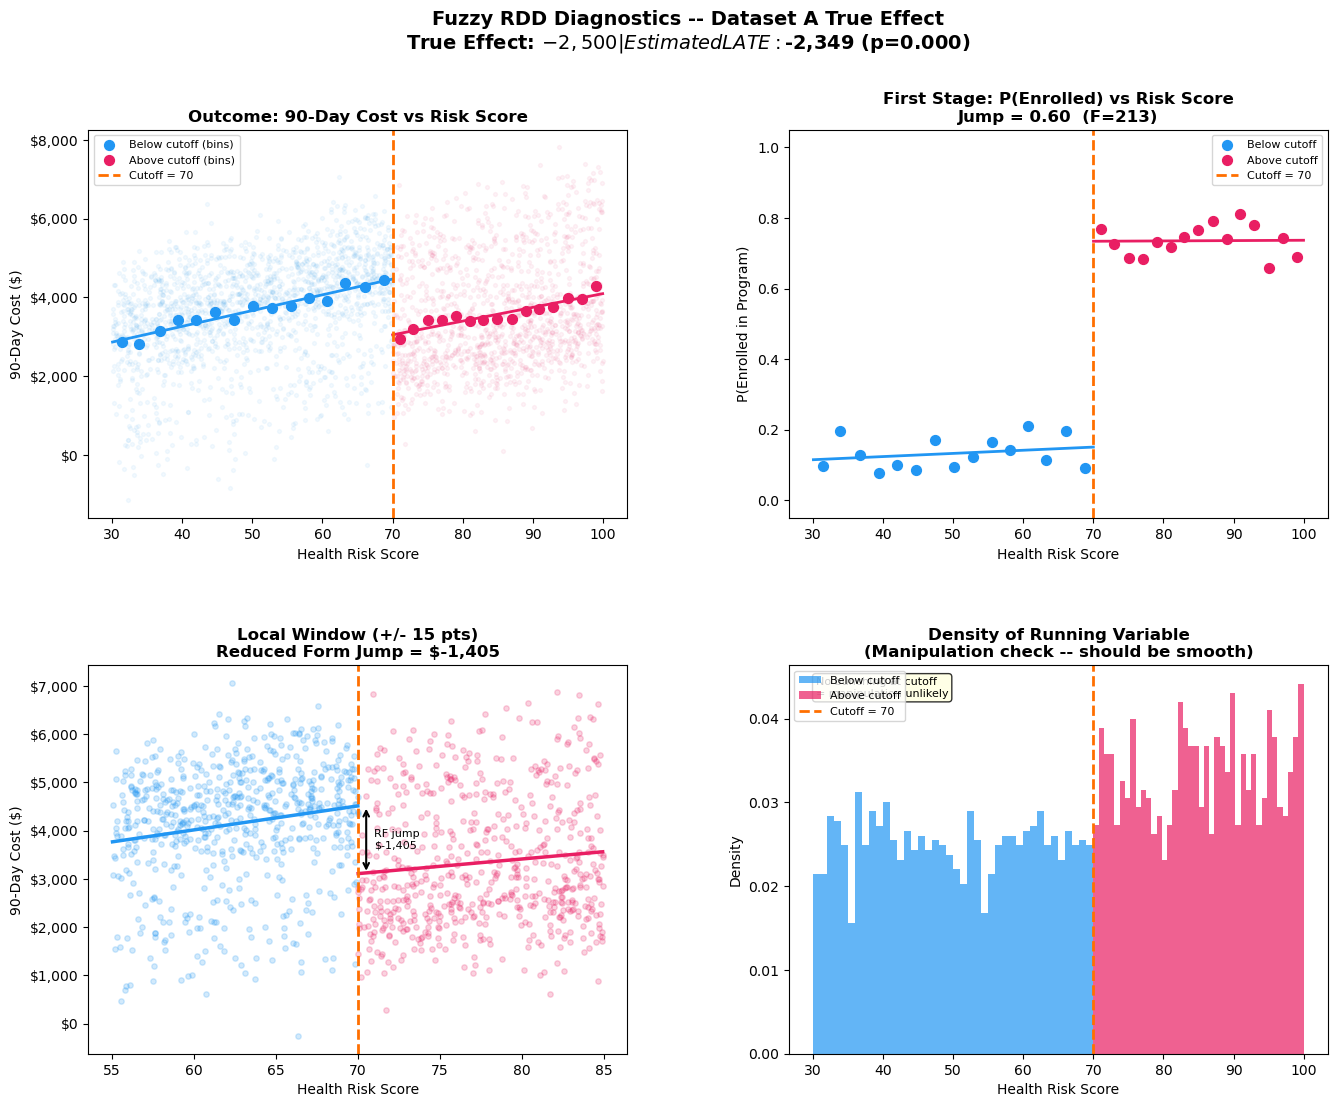


Figure saved.


In [41]:
"""
    In Dataset A:
    - Members above the cutoff are more likely to enroll (fuzzy treatment)
    - Enrollment actually causes costs to drop by $2,500
    - We should detect a negative, significant LATE
"""
df_a = generate_dataset(
    n=N, cutoff=CUTOFF,
    true_effect=-2500,
    seed=42,
    label="Dataset A: True Effect (-$2,500)"
)

result_a = fuzzy_rdd(
    df_a, cutoff=CUTOFF, bandwidth=BANDWIDTH,
    label="Dataset A: True Effect"
)

plot_rdd(df_a, result_a, CUTOFF, BANDWIDTH,
         dataset_label="Dataset A True Effect",
         true_effect=-2500)

In [42]:
# --------------------------------------------------------
# DATASET B: NULL CASE -- NO CAUSAL EFFECT
# Enrollment has zero true effect on costs.
# Any naive comparison is driven entirely by selection bias
# (sicker people both score higher AND cost more -- confounded!)
# RDD should correctly return a near-zero LATE here
# --------------------------------------------------------


Dataset: Dataset B: Null (No Effect)
N = 3,000  |  Cutoff = 70  |  True effect = $0

First stage (take-up rates):
  Below cutoff: 13.9% enrolled
  Above cutoff: 75.7% enrolled

Outcome summary (mean 90-day cost):
  Below cutoff: $4,008
  Above cutoff: $5,407

Fuzzy RDD Estimation -- Dataset B: Null
Bandwidth: +/- 15 points around cutoff=70
Observations in bandwidth: 1,330 of 3,000

First Stage (DV = enrolled):
  Jump at cutoff: 0.583  (p=0.0000)
  F-statistic:    254.7  [STRONG]

Reduced Form (DV = cost):
  Jump at cutoff: $117  (p=0.1545)

LATE (Wald / IV Estimate):
  LATE = $200  (SE=$141)
  t-stat: 1.42  |  p-value: 0.1570
  95% CI: [$-77,  $477]
  >> NOT statistically significant -- consistent with no effect


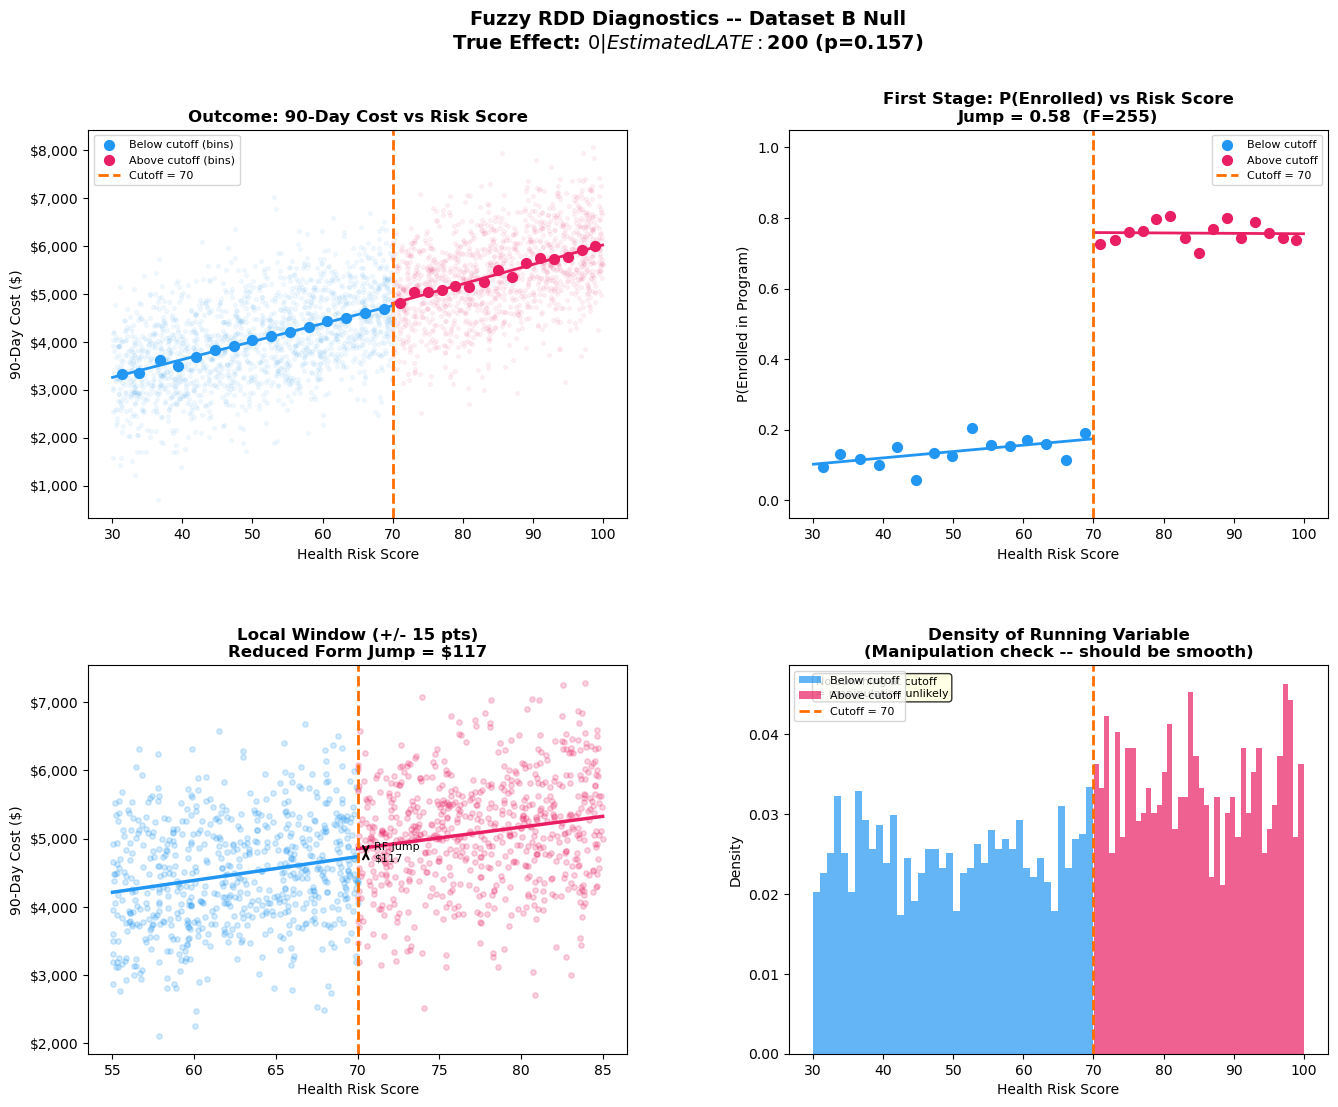


Figure saved.


In [43]:
"""
In Dataset B:
- Same fuzzy enrollment structure
- But enrollment does NOT change costs (true_effect = 0)
- The running variable (score) still correlates with cost (sicker = more expensive)
- A naive enrolled vs not-enrolled comparison would STILL show a spurious
  correlation because sicker people enroll more AND cost more
- RDD corrects for this: it only looks at the discontinuity AT THE CUTOFF
- We should find a non-significant LATE near $0
"""
df_b = generate_dataset(
    n=N, cutoff=CUTOFF,
    true_effect=0,
    seed=99,
    label="Dataset B: Null (No Effect)"
)

result_b = fuzzy_rdd(
    df_b, cutoff=CUTOFF, bandwidth=BANDWIDTH,
    label="Dataset B: Null"
)

plot_rdd(df_b, result_b, CUTOFF, BANDWIDTH,
         dataset_label="Dataset B Null",
         true_effect=0)

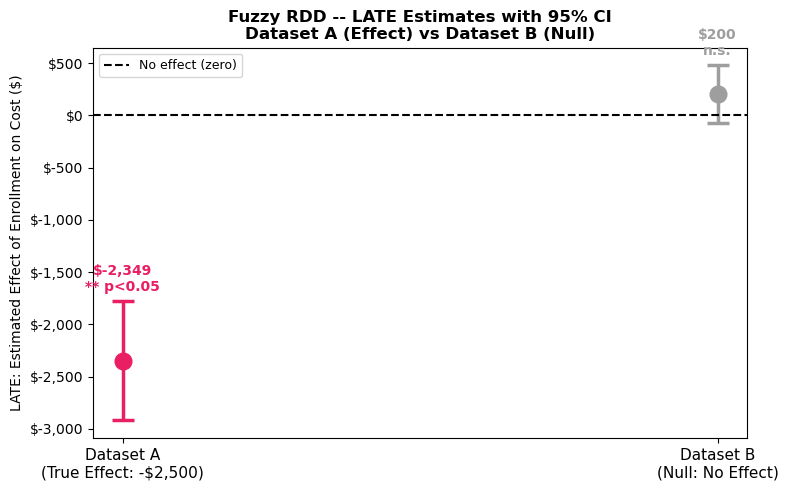

In [44]:
# --------------------------------------------------------
# COMPARISON PLOT: Both datasets side by side
# --------------------------------------------------------
plot_late_comparison(result_a, result_b)

In [45]:
# --------------------------------------------------------
# NAIVE COMPARISON: What happens without RDD?
# --------------------------------------------------------

In [46]:
"""
To illustrate WHY RDD matters, compare naive OLS (just regress cost ~ enrolled)
against the RDD estimate. In Dataset B, naive OLS will show a large spurious
negative effect simply because sicker members both enroll more AND cost more.
RDD eliminates this confound.
"""
print("\n" + "="*60)
print("NAIVE vs RDD COMPARISON (Dataset B -- Null Case)")
print("="*60)
naive_b = sm.OLS(
    df_b['cost'],
    sm.add_constant(df_b[['enrolled', 'score_centered']])
).fit()
print(f"\nNaive OLS coefficient on 'enrolled': ${naive_b.params['enrolled']:,.0f}"
      f"  (p={naive_b.pvalues['enrolled']:.4f})")
print(f"RDD LATE:                            ${result_b['late']:,.0f}"
      f"  (p={result_b['p_late']:.4f})")
print("\nNaive OLS picks up selection bias even when true effect = 0.")
print("RDD correctly recovers near-zero LATE because it exploits the cutoff.")


NAIVE vs RDD COMPARISON (Dataset B -- Null Case)

Naive OLS coefficient on 'enrolled': $-56  (p=0.1107)
RDD LATE:                            $200  (p=0.1570)

Naive OLS picks up selection bias even when true effect = 0.
RDD correctly recovers near-zero LATE because it exploits the cutoff.



Placebo Cutoff Test -- Dataset A True Effect


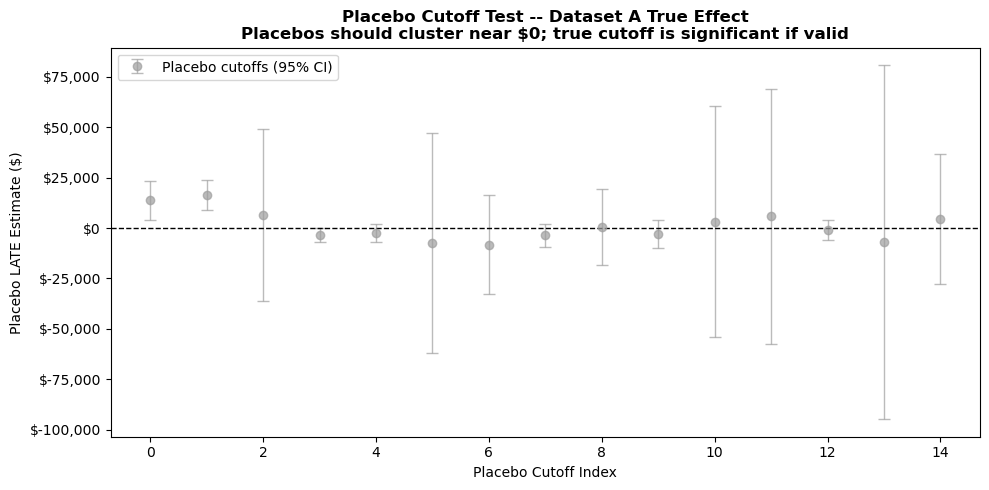

% of placebo cutoffs significant at 5%: 11%  (expect ~5% by chance)


([np.float64(13797.932324747442),
  np.float64(16412.649320432138),
  np.float64(6488.146864125976),
  np.float64(-3380.922796535551),
  np.float64(-2567.9836777280084),
  np.float64(-7568.044340997958),
  np.float64(-8340.61086350989),
  np.float64(-3486.6576359854193),
  np.float64(489.69789991195097),
  np.float64(-2950.0204854421845),
  np.float64(3176.68506389584),
  np.float64(5852.901992003159),
  np.float64(-1137.2319339727705),
  np.float64(-7022.182434855774),
  np.float64(4368.887479288473),
  np.float64(nan),
  np.float64(nan),
  np.float64(nan),
  np.float64(nan)],
 [np.float64(4981.444134168603),
  np.float64(3686.343551600542),
  np.float64(21727.257549806636),
  np.float64(1729.004725080733),
  np.float64(2297.4257609783076),
  np.float64(27852.154841709427),
  np.float64(12565.855649978266),
  np.float64(2890.919569233152),
  np.float64(9634.062598331479),
  np.float64(3583.9501809546),
  np.float64(29172.999973791888),
  np.float64(32340.19232782523),
  np.float64(254

In [47]:
# --------------------------------------------------------
# FALSIFICATION: PLACEBO CUTOFFS
# --------------------------------------------------------
placebo_cutoff_test(df_a, CUTOFF, BANDWIDTH,label="Dataset A True Effect")


Bandwidth Sensitivity -- Dataset A True Effect


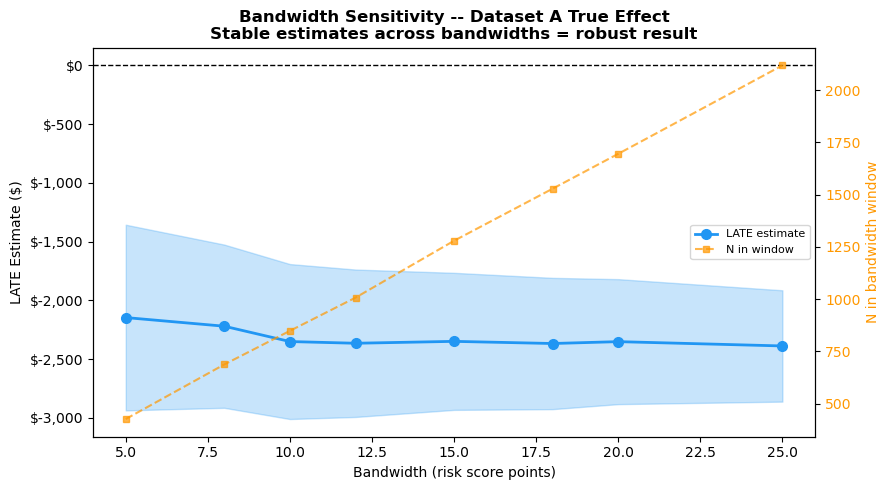


Bandwidth Sensitivity -- Dataset B Null


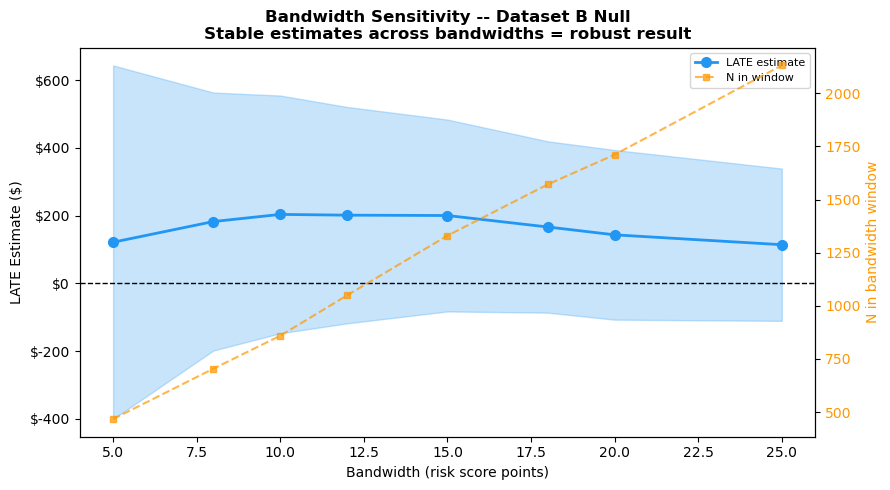

In [50]:
# --------------------------------------------------------
# ROBUSTNESS: BANDWIDTH SENSITIVITY
# --------------------------------------------------------
bandwidth_sensitivity(df_a, CUTOFF, label="Dataset A True Effect")
bandwidth_sensitivity(df_b, CUTOFF, label="Dataset B Null")

In [51]:
$# ---------------------------------------------------------------------
# HOW TO READ THE BANDWIDTH SENSITIVITY OUTPUT
#
# DATASET A -- True Effect (-$2,500):
#   The blue line should hover around -$2,500 across all bandwidth choices.
#   It will wobble slightly but should stay consistently negative and
#   significant -- meaning the shaded confidence band should NOT cross zero
#   at any bandwidth. That is your signal that the effect is real and robust.
#
# DATASET B -- Null Case (No Effect):
#   The blue line should float near $0 across all bandwidth choices.
#   The shaded confidence band should comfortably cross zero at every
#   bandwidth. No matter how wide or narrow you draw the window, you
#   should never find a consistent significant effect. That is your
#   signal that there is nothing there.
# ---------------------------------------------------------------------

SyntaxError: invalid syntax (813023835.py, line 1)

In [49]:
# --------------------------------------------------------
# FINAL SUMMARY
# --------------------------------------------------------
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"""
Dataset A (True effect = -$2,500):
LATE = ${result_a['late']:,.0f}  (95% CI: ${result_a['ci_low']:,.0f} to ${result_a['ci_high']:,.0f})
p = {result_a['p_late']:.4f}  --> {'SIGNIFICANT' if result_a['p_late'] < 0.05 else 'NOT SIGNIFICANT'}
First stage F = {result_a['fs_fstat']:.1f}  (instrument strength)

Dataset B (Null -- no effect):
LATE = ${result_b['late']:,.0f}  (95% CI: ${result_b['ci_low']:,.0f} to ${result_b['ci_high']:,.0f})
p = {result_b['p_late']:.4f}  --> {'SIGNIFICANT' if result_b['p_late'] < 0.05 else 'NOT SIGNIFICANT'}
First stage F = {result_b['fs_fstat']:.1f}  (instrument strength)

DS Takeaways:
  1. Fuzzy RDD = IV where eligibility cutoff is the instrument
  2. LATE only applies to compliers near the cutoff (local external validity)
  3. Always check: first stage F > 10, density continuity, placebo cutoffs
  4. Bandwidth is the key tuning parameter -- report sensitivity
  5. Naive OLS is biased when enrollment is endogenous -- RDD fixes this
     by exploiting quasi-random variation AT the threshold
""")


FINAL SUMMARY

Dataset A (True effect = -$2,500):
LATE = $-2,349  (95% CI: $-2,917 to $-1,780)
p = 0.0000  --> SIGNIFICANT
First stage F = 213.0  (instrument strength)

Dataset B (Null -- no effect):
LATE = $200  (95% CI: $-77 to $477)
p = 0.1570  --> NOT SIGNIFICANT
First stage F = 254.7  (instrument strength)

DS Takeaways:
  1. Fuzzy RDD = IV where eligibility cutoff is the instrument
  2. LATE only applies to compliers near the cutoff (local external validity)
  3. Always check: first stage F > 10, density continuity, placebo cutoffs
  4. Bandwidth is the key tuning parameter -- report sensitivity
  5. Naive OLS is biased when enrollment is endogenous -- RDD fixes this
     by exploiting quasi-random variation AT the threshold

